google authentication

In [1]:
!pip install gensim
!pip install spacy
!pip install medspacy
from google.colab import auth
auth.authenticate_user()
print('Authenticated')

Authenticated


### Big query authentication

In [2]:
from google.cloud import bigquery
project_id = 'ai-on-healthcare'
client = bigquery.Client(project=project_id)


In [3]:
#Atherosclerosis of native coronary artery
ICD_FILTER = ['41401']

diagnose_query = """
    SELECT *
    FROM `physionet-data.mimiciii_clinical.diagnoses_icd`
    LIMIT 1000000
"""

# Run the query and convert the results to a Pandas DataFrame
df_diagnoses = client.query(diagnose_query).to_dataframe()
df_diagnoses = df_diagnoses[df_diagnoses['ICD9_CODE'].isin(ICD_FILTER)]
subj_filtered = df_diagnoses['SUBJECT_ID'].unique()
print(subj_filtered)

<IntegerArray>
[  256,  1280,  3840,  4096,  4864,  7936, 76544, 76800, 77312, 12800,
 ...
 27391, 29183, 94975, 30463, 30975, 97023, 55807, 58111, 62975, 65535]
Length: 10775, dtype: Int64


get notes data

In [4]:
notes_query = """
    SELECT *
    FROM `physionet-data.mimiciii_notes.noteevents`
    LIMIT 10000
"""

# Run the query and convert the results to a Pandas DataFrame
df_notes = client.query(notes_query).to_dataframe()

df_notes_filtered = df_notes[df_notes['SUBJECT_ID'].isin(subj_filtered)]
df_notes_filtered.head(3)

,ROW_ID,SUBJECT_ID,HADM_ID,CHARTDATE,CHARTTIME,STORETIME,CATEGORY,DESCRIPTION,CGID,ISERROR,TEXT
0,435071,71353,178296,2123-12-31,2123-12-31 11:32:00,2123-12-31 17:54:04,Physician,CVI,16563,<NA>,TITLE:\n CVICU\n HPI:\n HD4\n POD\n ...
1,929999,14885,<NA>,2130-09-26,2130-09-26 00:00:00,NaT,Radiology,RVG,<NA>,<NA>,RVG ...
5,208896,26562,196533,2112-03-14,NaT,NaT,ECG,Report,<NA>,<NA>,Sinus tachycardia\nModest nonspecific low ampl...


extract entities

In [ ]:
import numpy as np

def tsne_plot(model,words, preTrained=False):
    "Creates and TSNE model and plots it"
    labels = []
    tokens = []

    for word in words:
      if preTrained:
          tokens.append(model[word])
      else:
          tokens.append(model.wv[word])
      labels.append(word)

    tokens = np.array(tokens)
    tsne_model = TSNE(perplexity=50, early_exaggeration=12, n_components=2, init='pca', n_iter=1000, random_state=23)
    new_values = tsne_model.fit_transform(tokens)

    x = []
    y = []
    for value in new_values:
        x.append(value[0])
        y.append(value[1])

    plt.figure(figsize=(16, 16))
    for i in range(len(x)):
        plt.scatter(x[i],y[i])
        plt.annotate(labels[i],
                     xy=(x[i], y[i]),
                     xytext=(5, 2),
                     textcoords='offset points',
                     ha='right',
                     va='bottom')
    plt.show()

In [6]:
import spacy
nlp = spacy.load("en_core_web_sm")
corpus=[]
for row in range(0, len(df_notes_filtered)):
  str_tokens=[]
  tokens= nlp(df_notes_filtered.iloc[row]['TEXT']).ents
  for i in range(0, len(tokens)):
    str_tokens.append(tokens[i].text)
  corpus.append(list(str_tokens))

corpus = [tok for note in corpus for tok in note]
print(len(corpus))

121129


### Get pretrained model

In [7]:
import gensim
import gensim.downloader as api
info = api.info()
pretrained_model= api.load("glove-wiki-gigaword-50")

[==================================================] 100.0% 66.0/66.0MB downloaded


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


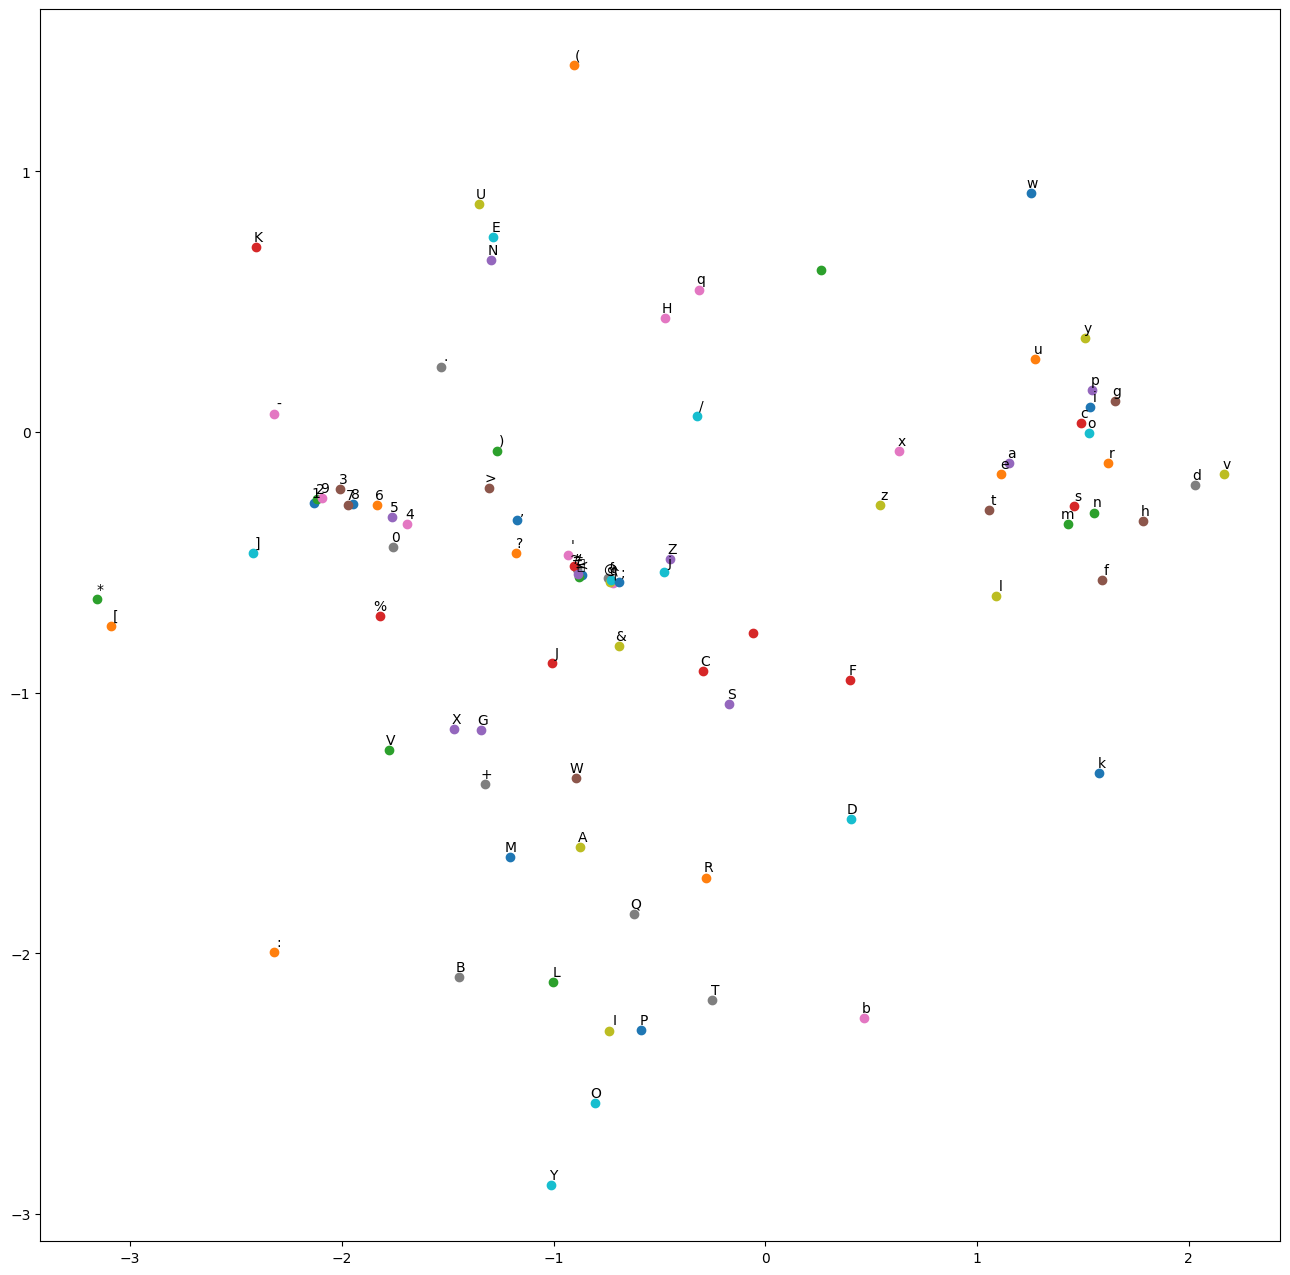

In [8]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from gensim.models import Word2Vec
model1 = Word2Vec(corpus, min_count=1)
vocabs = model1.wv.key_to_index.keys()
new_v = np.array(list(vocabs))
tsne_plot(model1,new_v)

In [9]:
!pip install -q --force-reinstall "spacy>=3.8,<4.0"
!pip install -q --no-deps https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.5.4/en_core_sci_sm-0.5.4.tar.gz

# Re-aplica el parche del config.cfg
import os, re, importlib, en_core_sci_sm
importlib.reload(en_core_sci_sm)
model_dir = os.path.dirname(en_core_sci_sm.__file__)
pattern = re.compile(r'include_static_vectors\s*=\s*"?(False|True)"?', re.IGNORECASE)
for root, _, files in os.walk(model_dir):
    for f in files:
        if f == "config.cfg":
            p = os.path.join(root, f)
            with open(p) as fh: text = fh.read()
            new_text, n = pattern.subn(lambda m: f"include_static_vectors = {m.group(1).lower()}", text)
            if n and new_text != text:
                with open(p, "w") as fh: fh.write(new_text)
                print("patched:", p)

import spacy
print("spacy:", spacy.__version__)

import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="spacy")
!pip install -q https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.5.4/en_core_sci_sm-0.5.4.tar.gz

# Parchear el config.cfg antes de cargar
import os, re, importlib
import en_core_sci_sm
model_dir = os.path.dirname(en_core_sci_sm.__file__)
pattern = re.compile(r'include_static_vectors\s*=\s*"?(False|True)"?', re.IGNORECASE)
for root, _, files in os.walk(model_dir):
    for f in files:
        if f == "config.cfg":
            p = os.path.join(root, f)
            with open(p) as fh: text = fh.read()
            new_text, n = pattern.subn(lambda m: f"include_static_vectors = {m.group(1).lower()}", text)
            if n and new_text != text:
                with open(p, "w") as fh: fh.write(new_text)
                print("patched:", p)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 6.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.4/109.4 kB 12.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.2/33.2 MB 36.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.8/260.8 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.1/134.1 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 85.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 869.0/869.0 kB 56.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.3/472.3 kB 41.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 95.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 78.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━

/usr/local/lib/python3.12/dist-packages/spacy/util.py:971: UserWarning: [W095] Model 'en_core_sci_sm' (0.5.4) was trained with spaCy v3.7.4 and may not be 100% compatible with the current version (3.8.14). If you see errors or degraded performance, download a newer compatible model or retrain your custom model with the current spaCy version. For more details and available updates, run: python -m spacy validate
  warnings.warn(warn_msg)


patched: /usr/local/lib/python3.12/dist-packages/en_core_sci_sm/en_core_sci_sm-0.5.4/config.cfg
spacy: 3.8.14
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 75.8 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.1/183.1 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 865.0/865.0 kB 59.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 19.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.8/50.8 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 116.6 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.1/65.1 kB 7.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pyrush 1.0

In [10]:
nlp_scispacy = spacy.load("en_ner_bc5cdr_md")

corpus_sci =[]
for row in range(0, len(df_notes_filtered)):
    str_tokens = []
    tokens = nlp_scispacy(df_notes_filtered.iloc[row]['TEXT']).ents
    for i in range(0, len(tokens)):
        str_tokens.append(tokens[i].text)
    corpus_sci.append(list(str_tokens))
corpus_sci_flat = [tok for note in corpus_sci for tok in note]
print(len(corpus_sci_flat))

OSError: [E050] Can't find model 'en_ner_bc5cdr_md'. It doesn't seem to be a Python package or a valid path to a data directory.

In [ ]:
model1 = Word2Vec(corpus_sci, min_count=1)
vocabs = model1.wv.key_to_index.keys()
new_v = np.array(list(vocabs))
tsne_plot(model1,new_v)

In [ ]:
import medspacy
nlp_medspacy = medspacy.load("en_core_sci_sm", disable=["medspacy_pyrush"])

corpus_med = []
for row in range(0, len(df_notes_filtered)):
    str_tokens = []
    tokens = nlp_medspacy(df_notes_filtered.iloc[row]['TEXT']).ents
    for i in range(0, len(tokens)):
        str_tokens.append(tokens[i].text)
    corpus_med.append(list(str_tokens))
corpus_med = [tok for note in corpus_med for tok in note]
print(len(corpus_med))


In [ ]:
model1 = Word2Vec(corpus_sci, min_count=1)
vocabs = model1.wv.key_to_index.keys()
new_v = np.array(list(vocabs))
tsne_plot(model1,new_v)